In [1]:
from modules import Embedder, Decoder
from dataset import LOBSTERLevel10Dataset
from torch.nn.modules.loss import MSELoss
from torch.utils.data import DataLoader
from torch import optim
from itertools import chain
import torch

LATENT_DIMS = 64
EPOCHS = 20

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

embedder = Embedder.to(device)
decoder = Decoder.to(device)

train_data = LOBSTERLevel10Dataset(train=True)
train_loader = DataLoader(train_data, shuffle=False, batch_size=1024)

optimizer = optim.Adam(chain(embedder.parameters(), decoder.parameters()), lr=3e-4)
loss = MSELoss()

for epoch in range(EPOCHS):
    # TODO
    # z = torch.zeros(...)
    # then inside the loop, do one round of embeddings, then shift this vector forward and run embeddings again
    # actually I don't think this can be batched????
    total_loss = 0
    for datum in train_loader:
        datum = datum.to(device)
        optimizer.zero_grad()
        z = embedder(datum)
        recon = decoder(z)
        recon_loss = loss(datum, recon)
        recon_loss.backward()
        optimizer.step()
        total_loss += recon_loss.item()
    print(f'Epoch {epoch+1} done, total reconstruction loss = {total_loss:1.3f}')

Epoch 1 done, total reconstruction loss = 29.747
Epoch 2 done, total reconstruction loss = 14.840
Epoch 3 done, total reconstruction loss = 10.843
Epoch 4 done, total reconstruction loss = 8.610
Epoch 5 done, total reconstruction loss = 7.041
Epoch 6 done, total reconstruction loss = 6.175
Epoch 7 done, total reconstruction loss = 4.883
Epoch 8 done, total reconstruction loss = 3.937
Epoch 9 done, total reconstruction loss = 3.465
Epoch 10 done, total reconstruction loss = 2.993
Epoch 11 done, total reconstruction loss = 2.692
Epoch 12 done, total reconstruction loss = 2.515
Epoch 13 done, total reconstruction loss = 2.235
Epoch 14 done, total reconstruction loss = 2.225
Epoch 15 done, total reconstruction loss = 2.071
Epoch 16 done, total reconstruction loss = 1.743
Epoch 17 done, total reconstruction loss = 1.671
Epoch 18 done, total reconstruction loss = 1.456
Epoch 19 done, total reconstruction loss = 1.450
Epoch 20 done, total reconstruction loss = 1.235


In [2]:
from dataset import load_dfs

books, _ = load_dfs()

In [26]:
import pandas as pd

prev_datum = books.loc[0]

books_recon = pd.DataFrame(columns=books.columns)

for batch in train_loader:
    batch = batch.to(device)
    with torch.no_grad():
        recon_tensor = decoder(embedder(batch))
    recon_df = LOBSTERLevel10Dataset.feature_sequence_to_df(recon_tensor, prev_datum)
    books_recon = pd.concat((books_recon, recon_df))
    prev_datum = recon_df.loc[len(recon_df) - 1]

/home/carson/projects/PatternAnalysis-2026/recognition/dataset.py:140: RuntimeWarning: invalid value encountered in scalar subtract
  [initial_book[f'ASKp{i+1}'] - initial_book[f'ASKp{i}'] for i in range(1, 10)],
/home/carson/projects/PatternAnalysis-2026/recognition/dataset.py:149: RuntimeWarning: invalid value encountered in scalar subtract
  [initial_book[f'BIDp{i}'] - initial_book[f'BIDp{i+1}'] for i in range(1, 10)],
/home/carson/projects/PatternAnalysis-2026/recognition/dataset.py:155: RuntimeWarning: overflow encountered in scalar add
  initial_midpoint = 0.5 * (initial_book['ASKp1'] + initial_book['BIDp1'])
/home/carson/projects/PatternAnalysis-2026/recognition/dataset.py:156: RuntimeWarning: invalid value encountered in scalar subtract
  initial_spread = initial_book['ASKp1'] - initial_book['BIDp1']


In [27]:
books

,ASKp1,ASKs1,BIDp1,BIDs1,ASKp2,ASKs2,BIDp2,BIDs2,ASKp3,ASKs3,...,BIDp8,BIDs8,ASKp9,ASKs9,BIDp9,BIDs9,ASKp10,ASKs10,BIDp10,BIDs10
0,2239500,100,2231800,100,2239900,100,2230700,200,2240000,220,...,2202500,5000,2294300,100,2202000,100,2298000,100,2189700,100
1,2239500,100,2238100,21,2239900,100,2231800,100,2240000,220,...,2204000,100,2294300,100,2202500,5000,2298000,100,2202000,100
2,2239500,100,2238100,21,2239600,20,2231800,100,2239900,100,...,2204000,100,2267700,100,2202500,5000,2294300,100,2202000,100
3,2239500,100,2238100,21,2239600,20,2237500,100,2239900,100,...,2213000,4000,2267700,100,2204000,100,2294300,100,2202500,5000
4,2239500,100,2238100,21,2239600,20,2237500,100,2239900,100,...,2213000,4000,2267700,100,2204000,100,2294300,100,2202500,5000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269743,2206200,100,2205100,249,2206400,100,2205000,71,2206500,1290,...,2204300,2300,2207600,100,2204200,100,2207900,2300,2204100,3300
269744,2206400,100,2205100,249,2206500,1290,2205000,71,2206700,170,...,2204300,2300,2207900,2300,2204200,100,2208000,3100,2204100,3300
269745,2206400,100,2205100,249,2206500,1290,2205000,71,2206700,170,...,2204300,2300,2208000,3100,2204200,100,2208100,1700,2204100,3300
269746,2206300,100,2205100,249,2206400,100,2205000,71,2206500,1290,...,2204300,2300,2207900,2300,2204200,100,2208000,3100,2204100,3300


In [28]:
books_recon

,ASKp1,ASKs1,BIDp1,BIDs1,ASKp2,ASKs2,BIDp2,BIDs2,ASKp3,ASKs3,...,BIDp8,BIDs8,ASKp9,ASKs9,BIDp9,BIDs9,ASKp10,ASKs10,BIDp10,BIDs10
0,2240256.5,100.183678,2232558.5,99.849197,2240655.75,99.997299,2231463.25,200.802139,2240755.75,220.185257,...,2203237.5,5008.671387,2295083.75,99.844177,2202737.5,100.379311,2298779.75,100.068047,2190468.25,99.858704
1,2195208.75,119.541763,2192073.75,17.676153,2195595.75,93.579521,2183524.75,95.23114,2195676.75,216.662857,...,2157771.25,102.66626,2240292.75,144.488403,2156082.75,4055.015869,2243202.75,110.399284,2155600.25,120.985237
2,2220280.5,112.127998,2216930.5,19.755663,2220414.0,19.542789,2207369.75,91.464325,2220891.0,95.41613,...,2181819.0,103.039902,2261928.25,128.429367,2180080.5,4269.322754,2284602.25,97.707977,2179630.25,103.828217
3,2195429.75,364.990906,2190964.25,23.822535,2195574.75,27.75737,2189781.25,87.3937,2196005.75,143.012131,...,2168449.75,5324.020996,2233459.0,118.722412,2164144.25,90.044266,2253865.0,106.034874,2163556.25,4520.140625
4,2196277.0,365.55603,2191809.5,23.788155,2196422.0,27.817703,2190628.5,87.653,2196853.75,143.361298,...,2169311.75,5328.338379,2234361.75,118.541084,2165006.0,90.425446,2254701.0,106.509079,2164419.5,4519.036621
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
929,NaN,inf,NaN,0.0,NaN,0.0,NaN,inf,NaN,inf,...,NaN,0.0,NaN,inf,NaN,inf,NaN,inf,NaN,0.0
930,NaN,inf,NaN,0.0,NaN,0.0,NaN,inf,NaN,inf,...,NaN,0.0,NaN,inf,NaN,inf,NaN,inf,NaN,0.0
931,NaN,inf,NaN,0.0,NaN,0.0,NaN,inf,NaN,inf,...,NaN,0.0,NaN,inf,NaN,inf,NaN,inf,NaN,0.0
932,NaN,inf,NaN,0.0,NaN,0.0,NaN,inf,NaN,inf,...,NaN,0.0,NaN,inf,NaN,inf,NaN,inf,NaN,0.0


In [6]:
import numpy as np

books_midpoints = np.array(0.5 * (books['ASKp1'] + books['BIDp1']))

In [7]:
recon_midpoints = np.array(0.5 * (books_recon['ASKp1'] + books_recon['BIDp1']))

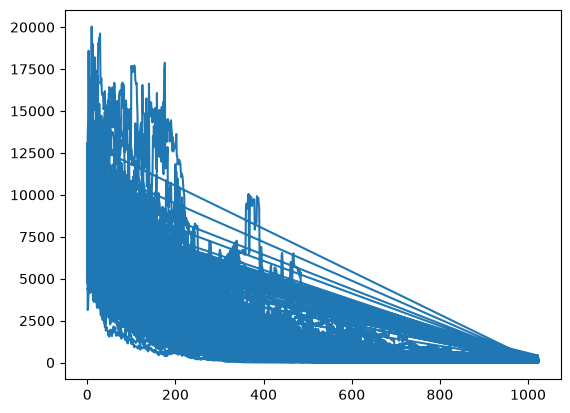

In [20]:
import matplotlib.pyplot as plt

#plt.plot(books['ASKp1'] - books['BIDp1'])
plt.plot(books_recon['ASKp1'] - books_recon['BIDp1'])